<a href="https://colab.research.google.com/github/2303a51019/Data-Analaysis/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

if torch.cuda.is_available():
    print("CUDA is available! Device name:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Using CPU.")

CUDA is available! Device name: Tesla T4


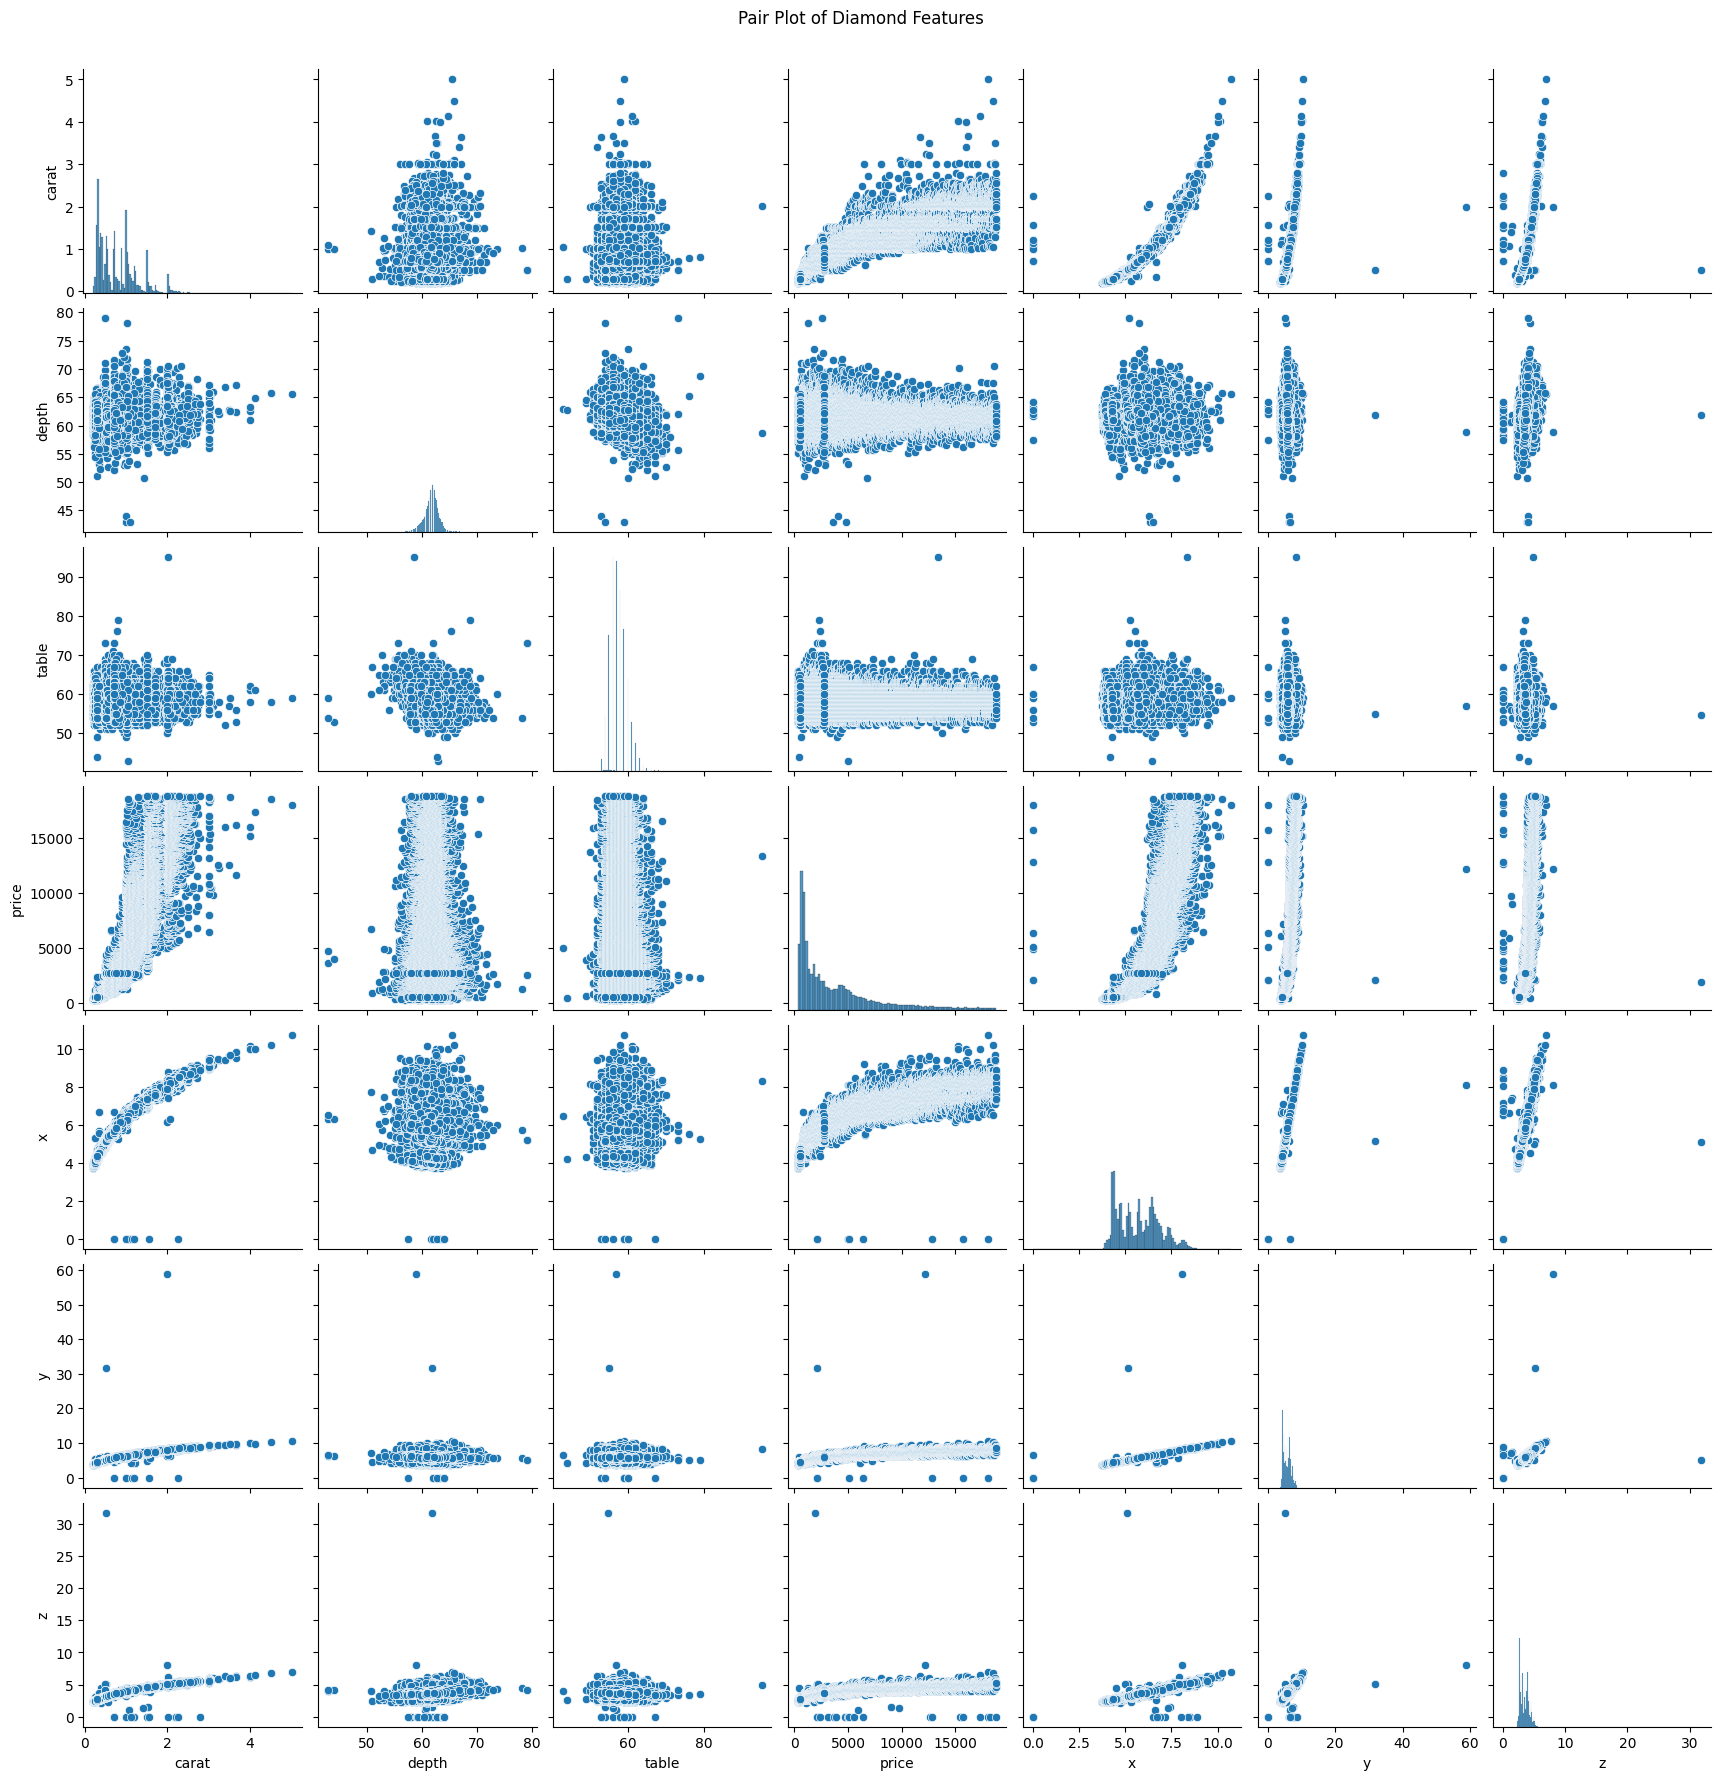

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a pair plot for the diamonds_df DataFrame
sns.pairplot(diamonds_df)
plt.suptitle('Pair Plot of Diamond Features', y=1.02) # Add a title to the plot
plt.show()

### 1. Data Preprocessing

First, we need to prepare the `diamonds_df` for machine learning. This involves converting categorical features into numerical ones using one-hot encoding and then splitting the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define features (X) and target (y)
X = diamonds_df.drop('price', axis=1)
y = diamonds_df['price']

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=['cut', 'color', 'clarity'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Display the first few rows of the preprocessed features
display(X_train.head())

Shape of X_train: (43152, 23)
Shape of X_test: (10788, 23)
Shape of y_train: (43152,)
Shape of y_test: (10788,)


,carat,depth,table,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
26546,2.01,58.1,64.0,8.23,8.19,4.77,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
9159,1.01,60.0,60.0,6.57,6.49,3.92,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
14131,1.10,62.5,58.0,6.59,6.54,4.10,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
15757,1.50,61.5,65.0,7.21,7.17,4.42,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
24632,1.52,62.1,57.0,7.27,7.32,4.53,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False


### 2. Model Training and Evaluation

Now, let's train a few different regression models and evaluate their performance on the test set. We'll use Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared ($R^2$) as evaluation metrics.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}")

# Convert results to a DataFrame for easier viewing
results_df = pd.DataFrame(results).T
display(results_df.round(2))


Training Linear Regression...
Linear Regression - MAE: 737.15, MSE: 1288705.48, R2: 0.92

Training Random Forest...
Random Forest - MAE: 277.05, MSE: 309881.72, R2: 0.98

Training Gradient Boosting...
Gradient Boosting - MAE: 419.56, MSE: 609111.57, R2: 0.96


,MAE,MSE,R2
Linear Regression,737.15,1288705.48,0.92
Random Forest,277.05,309881.72,0.98
Gradient Boosting,419.56,609111.57,0.96


### 3. Visualize Comparative Analysis

Finally, let's visualize the performance of these models to easily compare their results.

/tmp/ipykernel_5689/1661235303.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_5689/1661235303.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MSE', data=results_df, ax=axes[1], palette='magma')
/tmp/ipykernel_5689/1661235303.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[2], palette='cividis')


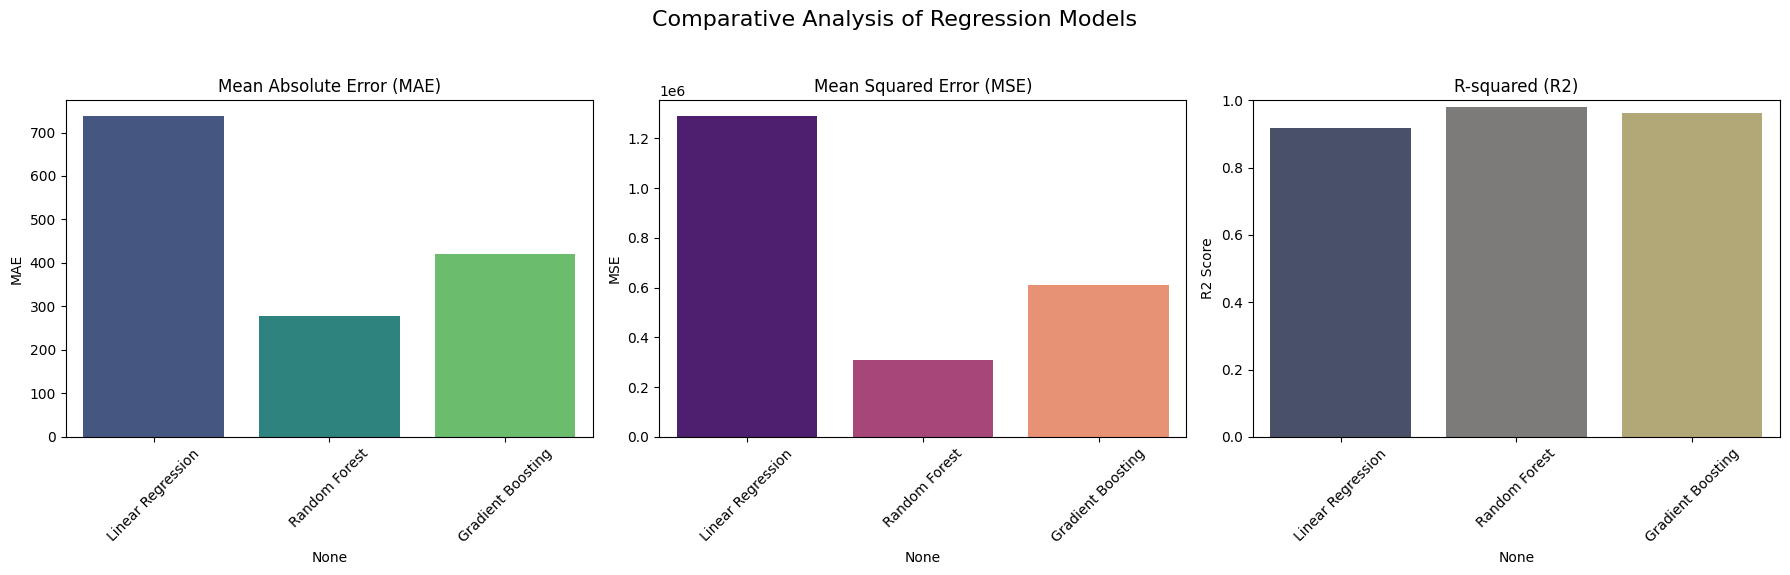

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparative Analysis of Regression Models', fontsize=16)

# Plot MAE
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# Plot MSE
sns.barplot(x=results_df.index, y='MSE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Squared Error (MSE)')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=45)

# Plot R2
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[2], palette='cividis')
axes[2].set_title('R-squared (R2)')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0, 1) # R2 typically ranges from 0 to 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd

# Load the diamonds dataset
diamonds_df = sns.load_dataset('diamonds')

# Display the first 5 rows of the dataset
display(diamonds_df.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
